In [4]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import time

# Seed for reproducibility
np.random.seed(42)

# Generate clusters
cluster1 = np.random.normal(loc=[2, 2], scale=0.5, size=(100, 2))
cluster2 = np.random.normal(loc=[8, 3], scale=0.5, size=(100, 2))
cluster3 = np.random.normal(loc=[5, 7], scale=0.5, size=(100, 2))


data = np.vstack([cluster1, cluster2, cluster3])

# Number of clusters
k = 3

# Initialize centers randomly
centers = data[np.random.choice(len(data), k, replace=False)]


In [5]:
# Function to assign clusters
def assign_clusters(data, centers):
    distances = np.sqrt(((data - centers[:, np.newaxis]) ** 2).sum(axis=2))
    return np.argmin(distances, axis=0)

# Function to update centers
def update_centers(data, labels, k):
    return np.array([data[labels == i].mean(axis=0) for i in range(k)])

# Function to run K-means and visualize updating
def kmeans_visualize(data, k, max_iters=100):
    # Initialize centers randomly
    centers = data[np.random.choice(len(data), k, replace=False)]
    
    # Create a new figure for each iteration
    plt.figure(figsize=(10, 6))
    
    for i in range(max_iters):
        # Assign clusters
        labels = assign_clusters(data, centers)
        
        # Clear previous plot
        plt.clf()
        
        # Plot data points with color based on cluster
        for j in range(k):
            cluster_points = data[labels == j]
            plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {j + 1}')
        
        # Update centers
        new_centers = update_centers(data, labels, k)
        
        # Plot centers
        plt.scatter(centers[:, 0], centers[:, 1], color='black', marker='x', s=100, label='Old Centers')
        plt.scatter(new_centers[:, 0], new_centers[:, 1], color='red', marker='x', s=100, label='New Centers')
        
        # Check convergence
        if np.all(new_centers == centers):
            break
            
        centers = new_centers  # Update centers for next iteration
        
        # Plot customization
        plt.title(f'Iteration {i + 1}')
        plt.legend(loc='upper left')
        
        # Display the plot
        display.clear_output(wait=True)
        display.display(plt.gcf())
        time.sleep(0.5)
    
    plt.show()

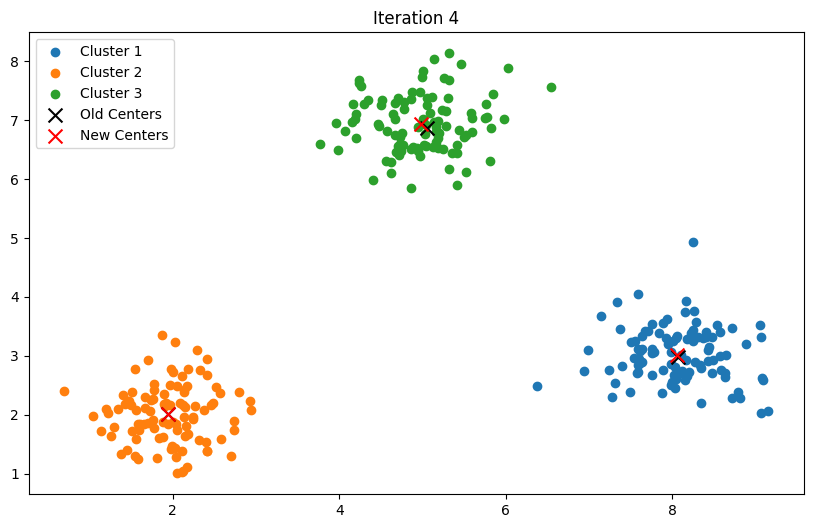

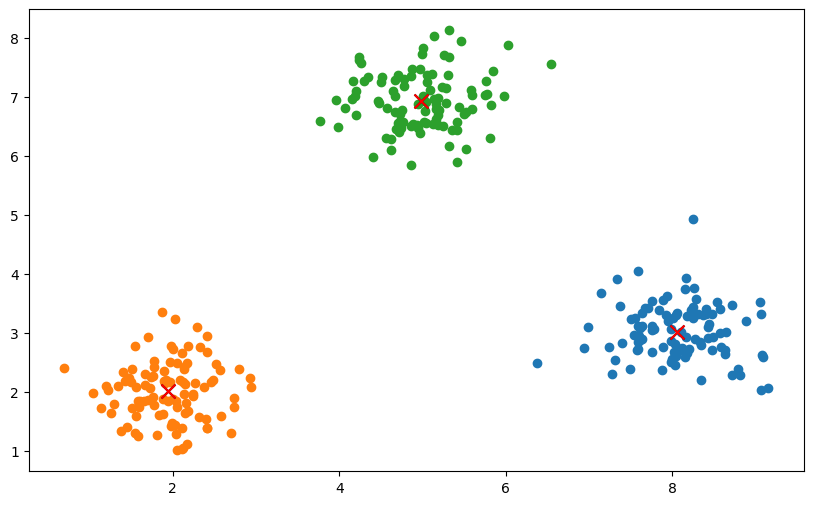

In [6]:

# Run and visualize K-means
kmeans_visualize(data, k)

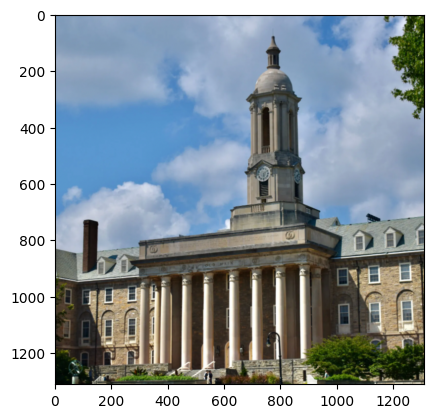

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
 
 
# Read in the image
image = cv2.imread('oldmain.png')
 
# Change color to RGB (from BGR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
 
plt.imshow(image)

In [13]:
# Reshaping the image into a 2D array of pixels and 3 color values (RGB)
pixel_vals = image.reshape((-1,3))
 
# Convert to float type
pixel_vals = np.float32(pixel_vals)

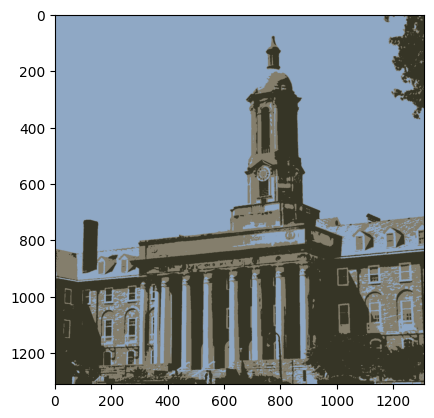

In [14]:
#the below line of code defines the criteria for the algorithm to stop running, 
#which will happen is 100 iterations are run or the epsilon (which is the required accuracy) 
#becomes 85%
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.85)
 
# then perform k-means clustering with number of clusters defined as 3
#also random centres are initially choosed for k-means clustering
k = 3
retval, labels, centers = cv2.kmeans(pixel_vals, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
 
# convert data into 8-bit values
centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
 
# reshape data into the original image dimensions
segmented_image = segmented_data.reshape((image.shape))
 
plt.imshow(segmented_image)

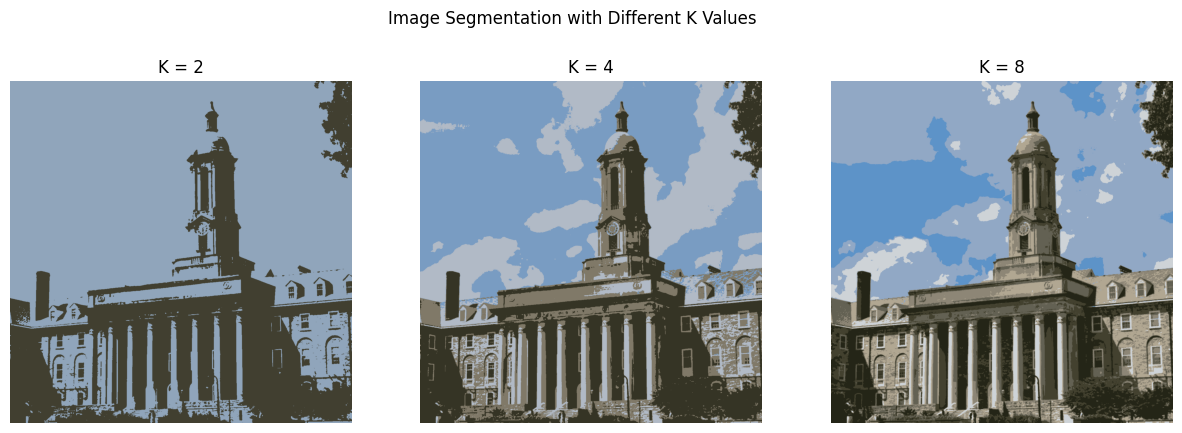

In [11]:
k_values = [2, 4, 8]
fig, axes = plt.subplots(1, len(k_values), figsize=(15, 5))
for i, k in enumerate(k_values):
    # Initialize centers randomly for each k
    centers = pixels[np.random.choice(len(pixels), k, replace=False)]
    
    # Run K-means until convergence
    for _ in range(100):  # Limit iterations to prevent infinite loops
        labels = assign_clusters(pixels, centers)  # Assign clusters
        centers = update_centers(pixels, labels, k)  # Update centers
    
    # Replace each pixel with its center color
    segmented_array = centers[labels].reshape(img_array.shape)
    # Plot
    axes[i].imshow(segmented_array.astype(np.uint8))
    axes[i].set_title(f'K = {k}')
    axes[i].axis('off')
plt.suptitle('Image Segmentation with Different K Values')
plt.show()